<center>
    <h1 style="
        background-color: #1f6f5f;
        color: #f8fafc;
        padding: 10px;
        font-size: 30px;
        border-radius: 10px;
        box-shadow: 0 2px 8px rgba(0,0,0,0.15);
    ">
        <strong>Computational Intelligence For Optimization 2025/2026 - Hill Climbing</strong>
    </h1>
</center>

**Student ID's:**

Andreea Roica: 20250361

Carlos Amorim: 20211548

Libero Biagi: 20250349

Oliver Kain: 20250401

In this notebook, we will take a look at an approach used to approximate a painting using one of the algorithms proposed in class: our own version of hill climbing. 

*Disclaimer*

In this notebook, we can see an exhaustive run (30k iterations on 5 individuals to check the potentialities of our algorithm), while for the comparison with our genetic algorithm we used 100 individuals with 500 iterations.

<h1 style="
    background-color: rgba(46, 125, 50, 0.55);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> Index </strong>
</h1>

[1. **Imports**](#imports)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[1.1 **Import Image**](#import-image)<br>

[2. **Utility Functions**](#utility-functions)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.1 **Initialization Functions**](#initialization-functions)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.2 **Optimization Functions**](#optimization-functions)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.3 **Analytical Functions**](#analytical-functions)<br>

[3. **Exhaustive Run**](#exhaustive-run)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.1 **Initial Population**](#initial-population)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.2 **Hill Climbing Algorithm**](#hill-climbing-algorithm)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.3 **Fitness Evaluation Plot**](#fitness-evaluation-plot)<br>

<h1 style="
    background-color: rgba(56, 142, 60, 0.45);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> 1. Imports </strong>
</h1>

In [39]:
from PIL import Image, ImageDraw
import numpy as np
import random
from scipy.ndimage import gaussian_filter
import pandas as pd
import matplotlib.pyplot as plt
import random
import copy
import os
import csv

from hill_functions import *

### 1.1. Import Image

In [40]:
# Load the image from file
img = Image.open("girl_pearl_earing.png").convert("RGB")

# Convert the image into a NumPy array
picture = np.array(img)

# Print the shape of the array
print(picture.shape)

h, w, _ = picture.shape

(400, 300, 3)


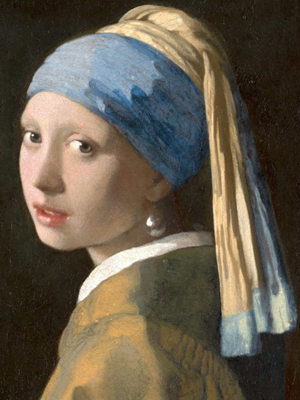

In [41]:
display(img)

As we can see, our image is "Girl with a Pearl Earring" (1865, original name "Meisje met de parel") by Johannes Vermeer (1632-1675). 

<h1 style="
    background-color: rgba(56, 142, 60, 0.45);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> 2. Utility Functions </strong>
</h1>

This section introduces the main components and parameters used throughout the notebook. The following functions define the core workflow behind our image reconstruction approach.

### 2.1. Initialization Functions


<p style="font-style: italic; color: #666;">
How we generate the starting solutions
</p>

---

#### `generate_initial_population`

Generates an initial population of `pop_size` individuals, where each individual is composed of `n_triangles` triangles.

If a target image is available, triangles are preferentially sampled in regions with higher reconstruction error (*error-based sampling*). Otherwise, positions are initialized around random base points. Triangle colors are generated completely at random.

Each triangle is immediately rendered onto a temporary canvas, allowing subsequent triangles to be sampled according to the updated residual error. Triangle size also decreases progressively during generation, helping balance coarse and fine image details.

---

#### `render_and_fitness`

Renders an individual onto a black canvas by sequentially drawing all of its triangles.

After rendering, the function computes the fitness score using the RMSE (*Root Mean Squared Error*) between the generated image and the target image on a pixel-by-pixel basis.

The function returns both the rendered canvas and its corresponding error value — lower scores indicate better approximations of the target image.

---

#### `triangle_area`

Computes the area of a triangle from its three vertices using the Shoelace formula.

This function is mainly used during population initialization to reject degenerate or nearly invisible triangles whose area falls below a minimum threshold, ensuring that every triangle contributes meaningfully to the reconstruction process.

---

#### `draw_triangle`

Utility function responsible for drawing a filled triangle on a PIL image given a set of vertices and an RGB color.

It is used both during population initialization and during image rendering.

---

#### `random_triangle`

Generates a triangle biased toward high-error regions of the image during initialization.

This function progressively shifts from larger, more exploratory triangles to smaller, more localized ones as initialization proceeds. It uses an error map between the current canvas and the target image to preferentially sample base points in regions where reconstruction is poor. This helps the algorithm focus early triangle placement on areas that need the most improvement.


---

### 2.2. Optimization Functions 

<p style="font-style: italic; color: #666;">
How we improve each solution
</p>

---

#### `random_neighbor`

Generates a neighboring solution by randomly mutating a single triangle.

With equal probability, the mutation either:

- perturbs the triangle geometry by shifting each vertex up to `step_geo` pixels, or
- perturbs the triangle color by adding random noise up to `step_color` per RGB channel.

All resulting values are clipped to valid ranges. This function acts as the core mutation operator of the hill climbing procedure.

---

#### `random_neighbor_multi_tri`

Extension of `random_neighbor` that simultaneously mutates `n_tri` randomly selected triangles.

By applying larger and coordinated modifications, this operator helps the algorithm escape flatter regions of the fitness landscape and avoid premature convergence. It is invoked with a 30% probability during hill climbing.

---

#### `hill_climb_individual`

Optimizes a single individual using an enhanced hill climbing strategy.

The implementation includes:

- best-of-k neighbor sampling,
- adaptive step sizes that shrink after stagnation,
- and randomized restarts based on perturbations of the current global best solution.

The function continuously tracks the best score obtained throughout optimization and returns:

- the best individual found,
- its final fitness score,
- and the complete fitness history across iterations.

---

#### `_perturb`

Applies a strong random perturbation to approximately 20% of an individual’s triangles.

Both geometry and color are displaced proportionally to the chosen `strength` parameter. This mechanism is primarily used between restarts in `hill_climb_individual` to help escape deep local optima.

---

#### `hill_climb_population`

Executes `hill_climb_individual` for every individual in the population.

The function collects all fitness histories, pads them to equal length, and exports the results to a CSV file.

It also generates a plot showing:

- the mean fitness evolution,
- the associated standard deviation,
- and faint traces for individual runs.

Finally, the population is sorted by fitness and the top-k individuals are returned.

---

### 2.3. Analytical Functions

<p style="font-style: italic; color: #666;">
How we evaluate the optimization process
</p>

---

#### `render_top_k`

Renders the top-k individuals side by side using matplotlib.

Each solution is displayed as a collection of semi-transparent filled triangles over a gray background, with its RMSE score shown as the subplot title. The y-axis is inverted to match standard image coordinate conventions.

---

#### `save_fitness_csv`

Exports the fitness history of all individuals to a CSV file.

Each row corresponds to an iteration, while each column represents one individual. If optimization stops early due to patience-based termination, missing entries are filled with `None` values (`NaN` in the CSV output).

The function also prints the output path and the shape of the saved dataset.

<h1 style="
    background-color: rgba(56, 142, 60, 0.45);
    color: rgb(250, 250, 250);
    padding: 5px;
    font-size: 30px;
">
<strong> 3. Exhaustive Run </strong>
</h1>

We define the number of triangles per individual, as well as the number of individuals in the population. 

The target picture is also defined.

In [42]:
N_TRIANGLES = 100  #triangles per individual
POP_SIZE = 5    #individuals

target_array = picture.astype(float)

### 3.1. Initial Population

Here we build our initial population...

In [43]:
population = generate_initial_population(POP_SIZE, N_TRIANGLES, w, h)

results = []

for ind in population:
    img_rendered, score = render_and_fitness(ind, target_array, w, h)
    results.append((score, img_rendered))

results.sort(key=lambda x: x[0])
top_5 = results[:5]

... And here we see it


Top 5 results random population:


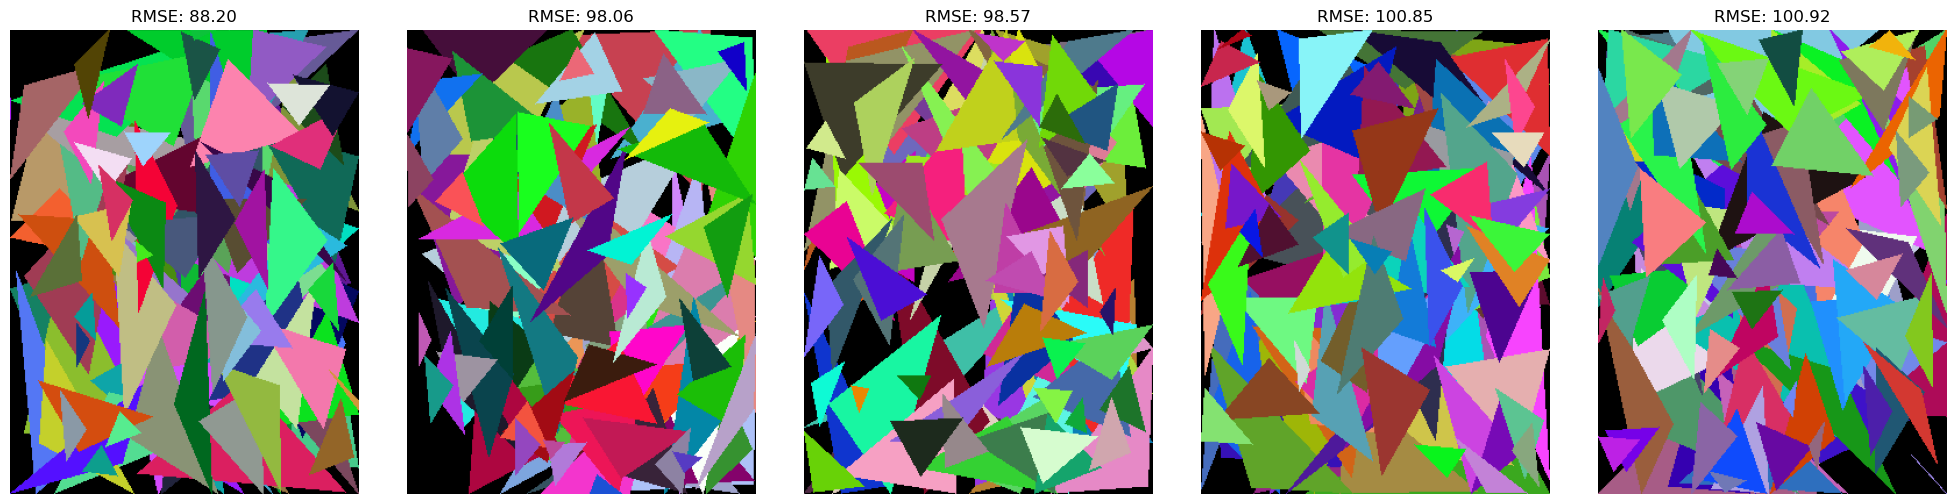

In [44]:
print("\nTop 5 results random population:")
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, (score, img_res) in enumerate(top_5):
    axes[i].imshow(img_res)
    axes[i].set_title(f"RMSE: {score:.2f}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

Now, we start improving these initial individuals in the direction of our target.

### 3.2. Hill Climbing Algorithm

In [45]:
top_inds, top_scores = hill_climb_population(
    population=population,
    target_array=picture,
    img_w=w,
    img_h=h,
    max_iterations=30000,
    patience=30000,
    top_k=5,
    n_restarts=3,
    n_candidates=5,
)

  Optimizing individual 1/5...
    → score: 18.8194
  Optimizing individual 2/5...
    → score: 19.9473
  Optimizing individual 3/5...
    → score: 19.8358
  Optimizing individual 4/5...
    → score: 20.2368
  Optimizing individual 5/5...
    → score: 21.2494
  → fitness saved to: /home/libero/Desktop/Computational-Intelligence-for-Optimization/hill_climbing/fitness_log.csv  (90000 rows, 5 individuals)


Here we see our top 5 individuals and their respective RMSE scores.

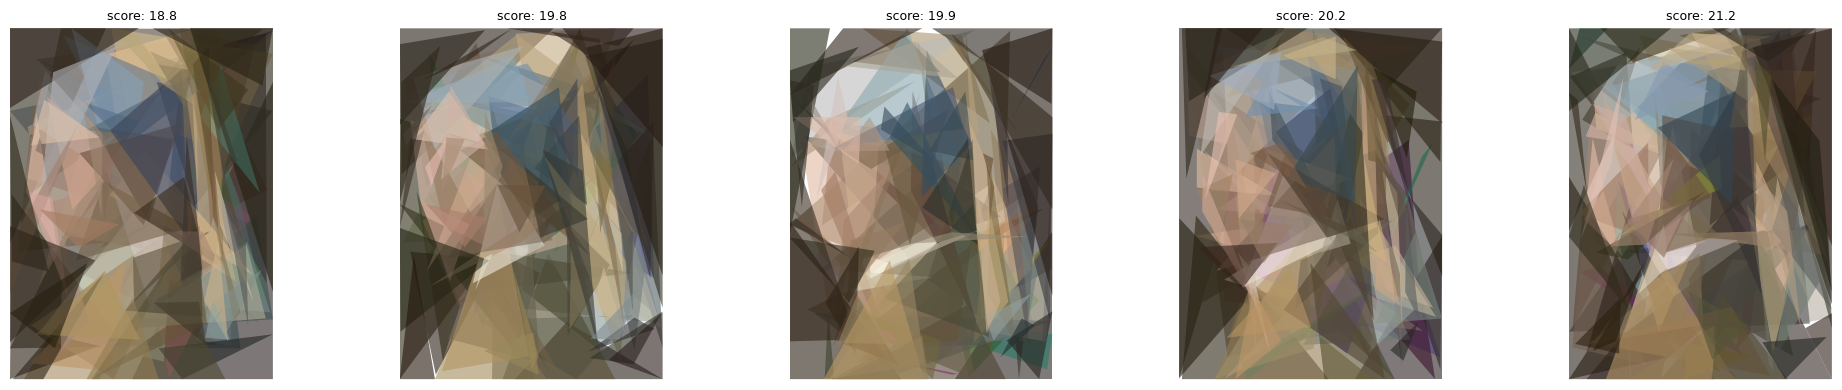

In [46]:
render_top_k(top_inds, top_scores, w, h)

### 3.3. Fitness Evaluation Plot

The following plot visualises how each individual's fitness (RMSE) evolves over the 30,000 hill climbing iterations.

Each red trace corresponds to one of the 5 individuals, while the blue line represents the mean fitness across the population. 
The shaded band marks the ±1 standard deviation range, giving a sense of how spread out the solutions are at each step.

A lower RMSE value means the reconstructed image is closer to the original *Girl with a Pearl Earring*, which means that downward movement is progress.

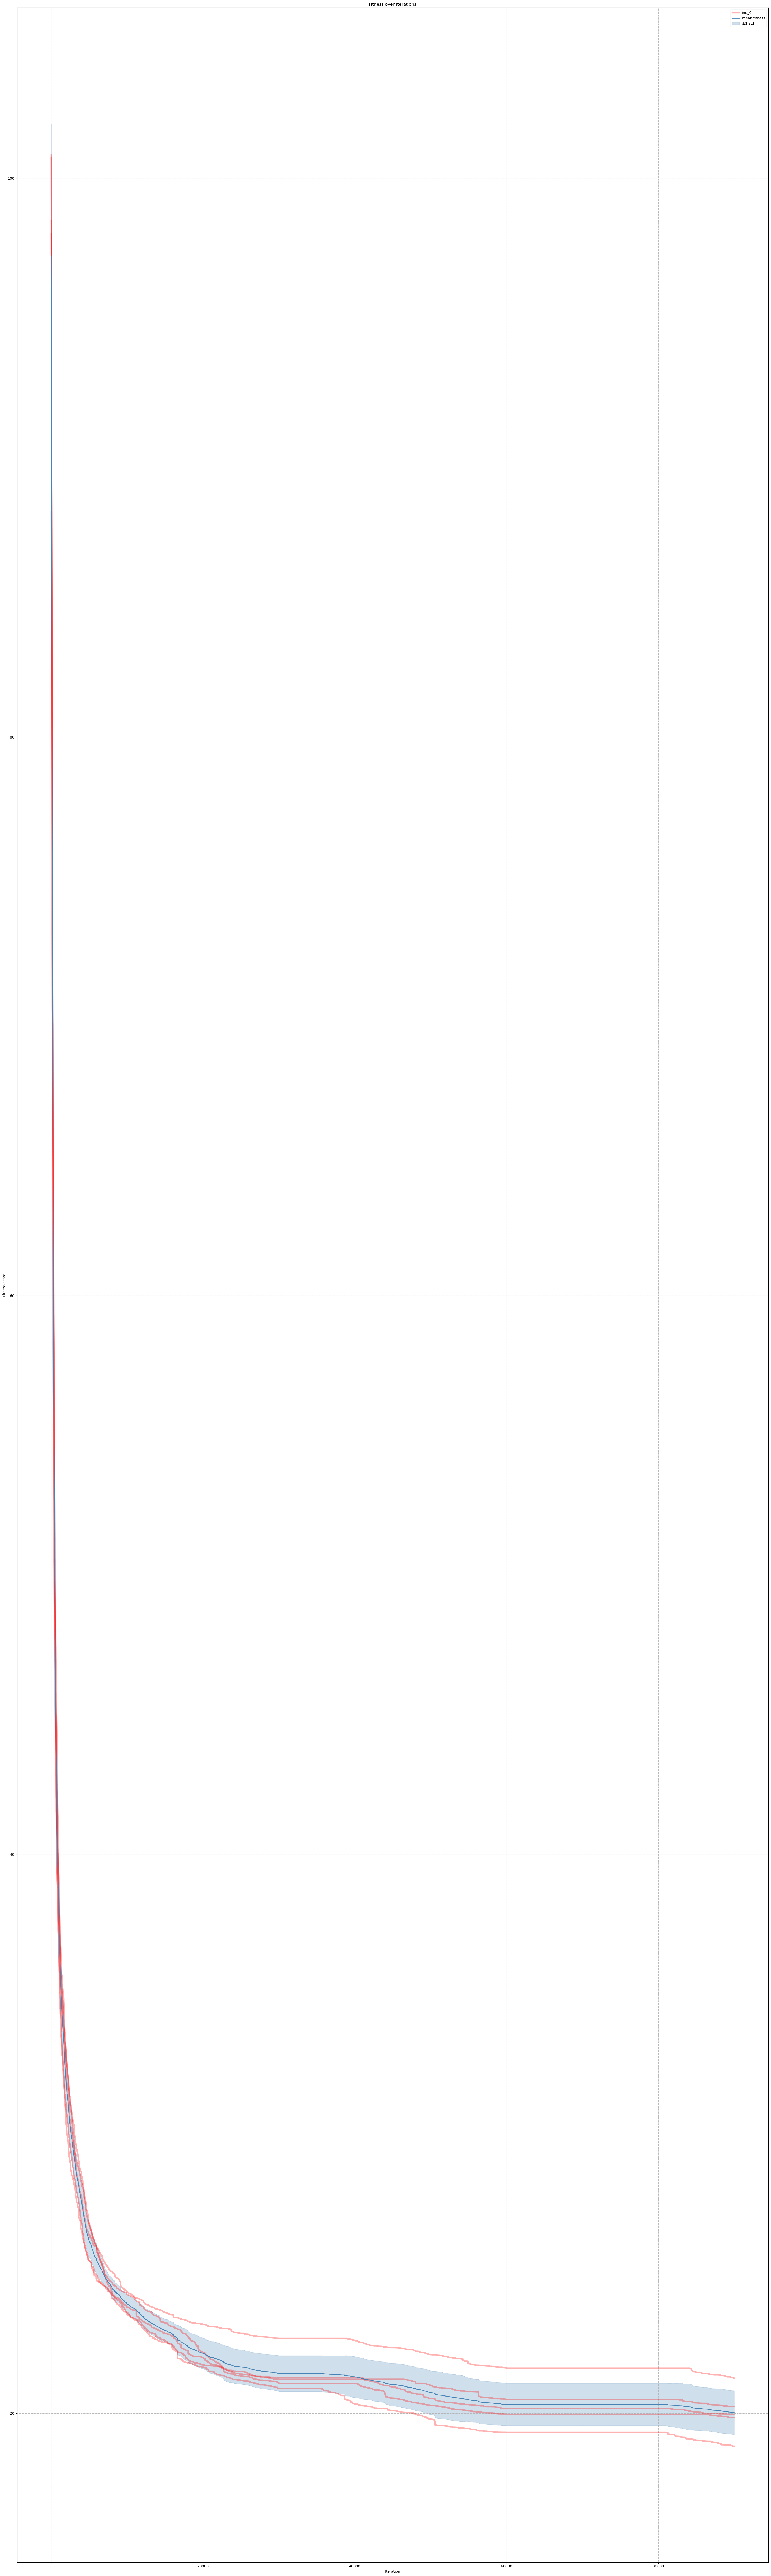

In [54]:
iterations = []
data = []

with open("fitness_log.csv", newline="") as f:
    reader = csv.DictReader(f)
    ind_cols = [c for c in reader.fieldnames if c != "iteration"]
    for row in reader:
        iterations.append(int(row["iteration"]))
        data.append([float(row[c]) for c in ind_cols])

iterations = np.array(iterations)
data       = np.array(data)   # shape: (n_iterations, n_individuals)

means = data.mean(axis=1)
stds  = data.std(axis=1)

fig, ax = plt.subplots(figsize=(30, 100))
for i, col in enumerate(ind_cols):
    ax.plot(iterations, data[:, i], color="red", alpha=0.3, linewidth=3.8, label=col if i == 0 else "_nolegend_")
ax.plot(iterations, means, label="mean fitness", color="steelblue", linewidth=2)
ax.fill_between(iterations, means - stds, means + stds, alpha=0.25, color="steelblue", label="±1 std")

ax.set_xlabel("Iteration")
ax.set_ylabel("Fitness score")
ax.set_title("Fitness over iterations")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.9)
plt.tight_layout()
plt.savefig("fitness_history.png", dpi=150)
plt.show()

Several patterns stand out:

- **Rapid early improvement:** Fitness drops sharply in the first few thousand iterations.
- **Diminishing returns:** Progress slows considerably past roughly 10k iterations, reflecting the algorithm settling into local optima.
- **Individual divergence:** The red traces spread apart over time, showing that different random seeds lead to qualitatively different local minima.
- **Restarts visible as dips/jumps:** Occasional sudden changes in a trace indicate a randomised restart, where the individual escapes a stagnating region at the cost of a temporary fitness setback before converging again.